source of data: [Mortality rates according to sex, educational level and age up to 100 years, and over](https://www.ine.es/jaxiT3/Tabla.htm?t=14816&L=1)<br>
wiki > [List of Spanish provinces by life expectancy](https://en.wikipedia.org/wiki/List_of_Spanish_provinces_by_life_expectancy) <i>([alternative](https://en.wikipedia.org/wiki/User:Lady3mlnm/List_of_Spanish_provinces_by_life_expectancy_(alternative)))</i>, [Political divisions of Spain](https://en.wikipedia.org/wiki/Political_divisions_of_Spain), [Provinces of Spain](https://en.wikipedia.org/wiki/Provinces_of_Spain)<br>
wiki > [Продолжительность жизни в провинциях Испании](https://ru.wikipedia.org/wiki/Продолжительность_жизни_в_провинциях_Испании), [Административное деление Испании](https://ru.wikipedia.org/wiki/Административное_деление_Испании), [Провинции Испании](https://ru.wikipedia.org/wiki/Провинции_Испании)<br />

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import math
import re
from collections import namedtuple

In [3]:
pd.options.display.min_rows = 8

In [4]:
LANGS = ['en']  # languages of the charts (this setting doesn't have influence on tables)  #['en', 'ru', 'nolang']
SELECTED_YEAR = 2024
WHAT_TO_EXPLORE = 'average' # What type of data to explore:
                            # 'single' - for a single year
                            # 'average' - average values over all years in load data
NAME_FOR_AVERAGE = '2022–2024'  # designation of the range of years used in titles of charts
WRITE_TABLE = False
DESTINATION_CHART = 'show'  # to where table code should be placed: 'file', 'show'

In [5]:
df = pd.read_csv('data/Mortality rate.csv', sep='\t', encoding='mbcs')  # encoding_errors='replace' ascii
print(df.shape)

df.head(2)

(918, 5)


,Regional totals,Sex,Age,Period,Total
0,National Total,Both genders,Total ages,2024,8.87
1,National Total,Both genders,Total ages,2023,8.96


In [6]:
df.drop(columns='Regional totals', inplace=True)
df = df[df['Age'] != 'Total ages']
print(df.shape)

df

(909, 4)


,Sex,Age,Period,Total
3,Both genders,0 years old,2024,3.01
4,Both genders,0 years old,2023,2.59
5,Both genders,0 years old,2022,2.56
6,Both genders,1 year old,2024,0.19
...,...,...,...,...
914,Females,99 years old,2022,350.96
915,Females,100 years or more,2024,431.33
916,Females,100 years or more,2023,432.06
917,Females,100 years or more,2022,483.10


In [7]:
pd.options.display.min_rows = 2

In [8]:
nmb_of_chars_removed = len(' years old')
df['Age'] = df['Age'].map(lambda st: '100' if st == '100 years or more' else \
                                     '1' if st == '1 year old' else          \
                                     st[:-nmb_of_chars_removed])             \
                     .astype(int)

df

,Sex,Age,Period,Total
3,Both genders,0,2024,3.01
...,...,...,...,...
917,Females,100,2022,483.10


<br>

In [10]:
def transform_df(df_inner):
    df_inner = pd.pivot_table(df_inner, values='Total', index='Age', columns='Sex')
    
    df_inner.index.name = ''
    df_inner.columns.name = ''
    df_inner = df_inner / 10  # move from 'Per mille' (‰) to percentage (%)
    return df_inner.rename(columns={'Both genders':'total', 'Females':'female', 'Males':'male'})

<br>

In [12]:
# df = df[df['Period'] == SELECTED_YEAR]
#        .drop(columns='Period')
#        if (WHAT_TO_EXPLORE == 'single')  else \
#      df.drop(columns='Period').groupby(['Sex', 'Age']).mean() if (WHAT_TO_EXPLORE == 'average') else \
#      None

# if (df is None):
#     raise ValueError("Variable WHAT_TO_EXPLORE has an invalid value")

# df

In [13]:
if (WHAT_TO_EXPLORE == 'single'):
    df = df[df['Period'] == SELECTED_YEAR] \
           .drop(columns='Period')
elif (WHAT_TO_EXPLORE == 'average'):
    df = df.drop(columns='Period')  \
           .groupby(['Sex', 'Age']) \
           .mean()
else:
     raise ValueError(f"Variable WHAT_TO_EXPLORE has an invalid value: '{WHAT_TO_EXPLORE}'")

df

,,Total
Sex,Age,
Both genders,0,2.720000
...,...,...
Males,100,510.926667


In [14]:
df = transform_df(df)
df = df[['male', 'total', 'female']]

# drop values for 100, since this record doesn't have sense
df.drop(index=100, inplace=True)

df['mΔf'] = df['male'] - df['female']
df['ratio_mf'] = (df['male'] / df['female']).round(2)

df

,male,total,female,mΔf,ratio_mf
,,,,,
0,0.298333,0.272000,0.244,0.054333,1.22
...,...,...,...,...,...
99,36.412667,34.220333,33.594,2.818667,1.08


<br>

<h4>Explore the "plateau"  (21–30 years)</h4>
The code below calculates average values of the probability of dying for the "plateau", and how much people would l

In [16]:
# just for fun, calculate average values during the "plateau" for the country and the separate regions
plateau_years = slice(21, 30)

dfe = df.loc[plateau_years, ['male', 'total', 'female']].mean().to_frame().T
dfe['ratio_mf'] = (dfe['male'] / dfe['female']).round(2)
dfe.index = ['Spain']
dfe.round(3)

,male,total,female,ratio_mf
Spain,0.04,0.028,0.016,2.4


In [17]:
# calculate average life expectancy if during the whole life of people the mortality rate will the the same as at the "plateau"
def calculate_average_LE_if_mortality_as_at_plateau(mortality_in_perc):
    mortality = mortality_in_perc / 100
    average_le = 1 / mortality
    return int(average_le)

dfe['le_ageless_male'] = dfe['male'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_total'] = dfe['total'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_female'] = dfe['female'].map(calculate_average_LE_if_mortality_as_at_plateau)
# dfe['ratio_ageless'] = (dfe['le_ageless_female'] / dfe['le_ageless_male']).round(2)  # values the same as in the columns 'ratio_mf'
dfe.round(3)

,male,total,female,ratio_mf,le_ageless_male,le_ageless_total,le_ageless_female
Spain,0.04,0.028,0.016,2.4,2525,3533,6060


<br>

<h4>Explore the zone of the Gompertz law of mortality  (40–90 years)</h4>
The code below calculates the average annual increase the probability of dying (in percent) and the period during that this indicator doubles (in years), <b>based on the values at the endpoints</b>.<br><i>
(Calculations based on approximation are below, under a chart.)</i>

In [19]:
def calculate_increase_rate_and_doubling_period(age1: int, age2: int, v1: float, v2: float):
    '''
    This function calculate two characteristics of a geometric progression (in the context of aging)
    - by what percentage does the value increase every year (in percent)
    - period of doubling (in years)
    '''
    q = math.pow((v2 / v1),
                  1 / (age2 - age1))  # find 'common ratio' of the geometric progression
                                      # (age2 - age1) √ (v2 / v1)      – (age2-age1)th root of (v2 / v1)

    T = math.log(2, q)  # doubling period:    log base 'q' of 2
    return (q - 1) * 100, T

In [20]:
age_gompertz_start = 40
age_gompertz_stop  = 90
print("increase_rate(%)  doubling   | increase_rate(%)  doubling")
print("            male             |             female")
male_rate_perc, male_period_double = \
    calculate_increase_rate_and_doubling_period(
        age_gompertz_start, age_gompertz_stop, df.loc[age_gompertz_start, 'male'], df.loc[age_gompertz_stop, 'male'])
female_rate_perc, female_period_double = \
    calculate_increase_rate_and_doubling_period(
        age_gompertz_start, age_gompertz_stop, df.loc[age_gompertz_start, 'female'], df.loc[age_gompertz_stop, 'female'])
print(f"      {male_rate_perc:5.2f} %  {male_period_double:5.2f} years   |" +
      f"       {female_rate_perc:5.2f} %  {female_period_double:5.2f} years")


increase_rate(%)  doubling   | increase_rate(%)  doubling
            male             |             female
      10.93 %   6.68 years   |       11.65 %   6.29 years


<br>

In [22]:
df.head()

,male,total,female,mΔf,ratio_mf
,,,,,
0,0.298333,0.272000,0.244000,0.054333,1.22
1,0.024667,0.021667,0.018000,0.006667,1.37
2,0.017667,0.016000,0.014667,0.003000,1.20
3,0.013000,0.012000,0.011000,0.002000,1.18
4,0.013000,0.011333,0.009333,0.003667,1.39


In [23]:
def create_table(df, file_header, lang='en'):

    def transform_value(x, prec=1):
        return f"{x:0.{prec}f}"

    
    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    prec = 3
    for age in [0, 1] + list(range(5, 96, 5)) + [99]:
        ser = df.loc[age]
        st += '\n' + '|-\n' + \
            f'|style="padding-right:3ex;"| {age} ' + \
            f'||style="color:blue;padding-right:3ex;"| {transform_value(ser.loc['male'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf']:0.2f}'

    # fix microbugs that can happened due to nuances of calculations and rounding
    st = st.replace('color:darkgray;padding-right:3ex;"| -0.0 ', 'color:darkgray;padding-right:3ex;"| 0.0 ')
    
    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits
        st = st.replace('padding-right:3ex;', 'padding-right:2.5ex;')

    st = table_header + st + '\n|}'
    return st


if WRITE_TABLE:
    file_name_table = \
        "Table code for probability of dying -single_year" if (WHAT_TO_EXPLORE == 'single')  else \
        "Table code for probability of dying -average"     if (WHAT_TO_EXPLORE == 'average') else \
        null
    
    table_code = create_table(df, file_header='Probability_of_dying -en.txt', lang='en')
    with open(f"output/{file_name_table} -en.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)

    table_code = create_table(df, file_header='Probability_of_dying -ru.txt', lang='ru')
    with open(f"output/{file_name_table} -ru.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)

<br>
<br>

In [25]:
DisplayedGroup = namedtuple('DisplayedGroup', ['en_name', 'ru_name', 'nolang_name', 'color', 'style', 'width', 'alpha'])

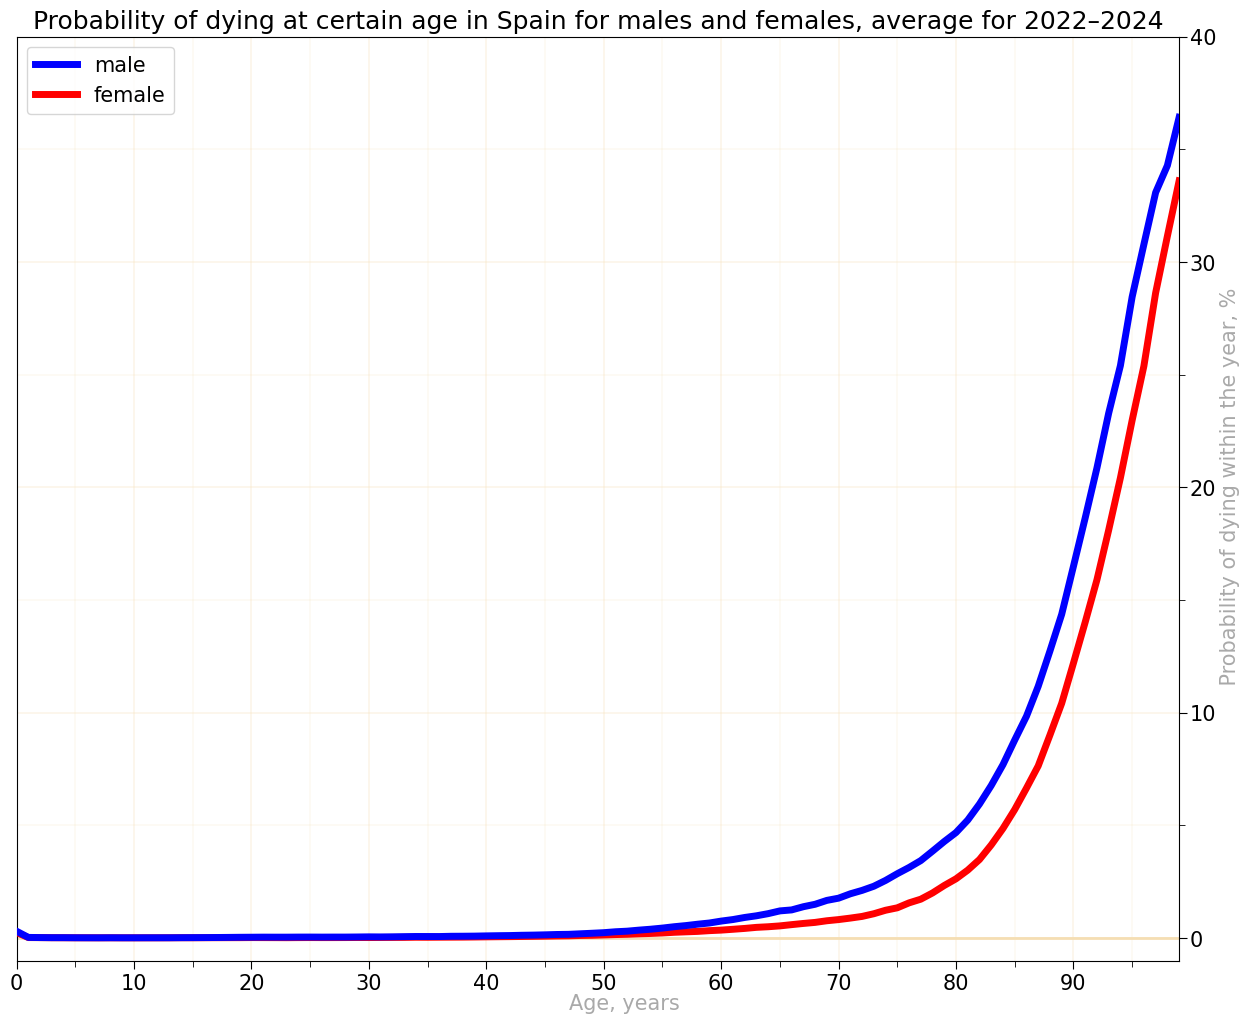

In [26]:
def create_chart(
        df, lang='en', dd_display='', ncol=1,
        title_en="Title of the chart", title_ru="Заголовок графика",
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.yaxis.tick_right()      # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(5))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)   # font size for tick labels
    plt.yticks(fontsize=15)
    
    x_min = y_min = 0
    x_max = 99
    y_max = 40
    plt.xlim(0, 99)
    plt.ylim(-1, 40)

    plt.grid(which='major', color='wheat', linewidth=0.35)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    plt.axhline(y=0, color='wheat', linewidth=2)

    plt.title(title_ru if lang=='ru' else " " if lang=='nolang' else title_en,
              fontsize=17 if lang=='ru' else 18)
    plt.xlabel("              Возраст, годы" if lang=='ru' else
               " " if lang=='nolang' else
               "        Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("     Вероятность смерти в течение года, %" if lang=='ru' else
               " " if lang=='nolang' else
               "    Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=3)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].nolang_name if lang=='nolang' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    plt.legend(loc='upper left', fontsize=15, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ' -nolang' if lang=='nolang' else ''}.png",
                    bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


dd_display = {
    'male'  : DisplayedGroup(en_name="male",   ru_name="мужчины", nolang_name="♂", color='blue', style='-', width=5, alpha=1),
    # 'total' : DisplayedGroup(en_name="overall", ru_name="в целом", nolang_name="∑", color='lightgrey', style='-', width=5, alpha=1),
    'female': DisplayedGroup(en_name="female", ru_name="женщины", nolang_name="♀", color='red',  style='-', width=5, alpha=1)
}

if (WHAT_TO_EXPLORE == 'single'):
    title_en=f"Probability of dying at certain age in Spain in {SELECTED_YEAR} for males and females"
    title_ru=f"Вероятность смерти в определённом возрасте в Испании в {SELECTED_YEAR} для мужчин и женщин"
    file_name=f"Probability of Dying at Certain Age in Spain"
elif (WHAT_TO_EXPLORE == 'average'):
    title_en=f"Probability of dying at certain age in Spain for males and females, average for {NAME_FOR_AVERAGE}"
    title_ru=f"Вероятность смерти в определённом возрасте в Испании для мужчин и женщин, {NAME_FOR_AVERAGE}"
    file_name=f"Probability of Dying at Certain Age in Spain 3 years average"
else:
     raise ValueError(f"Variable WHAT_TO_EXPLORE has an invalid value: '{WHAT_TO_EXPLORE}'")

for lang in LANGS:
    create_chart(df.T.loc[['male', 'female']],
            dd_display=dd_display, lang=lang, title_en=title_en, title_ru=title_ru, file_name=file_name)

  —— The zone of the 'plateau' (21–30 years, incl.) ——
Average mortality rate at the plateau, %:  ♂: 0.040,  ♀: 0.017
Life expectancy based on the average mortality rate at the plateau, years:  ♂: 2520,  ♀: 6060

  —— The zone of the Gompertz law of mortality (40–90 age_gompertz_stop) ——
Model for   male: y = 0.001536 * exp(0.101456 * x)
Coefficient of determination (R²): 0.986
Annual increase: 10.678 %,   doubling period:  6.832 years

Model for female: y = 0.000687 * exp(0.104172 * x)
Coefficient of determination (R²): 0.902
Annual increase: 10.979 %,   doubling period:  6.654 years



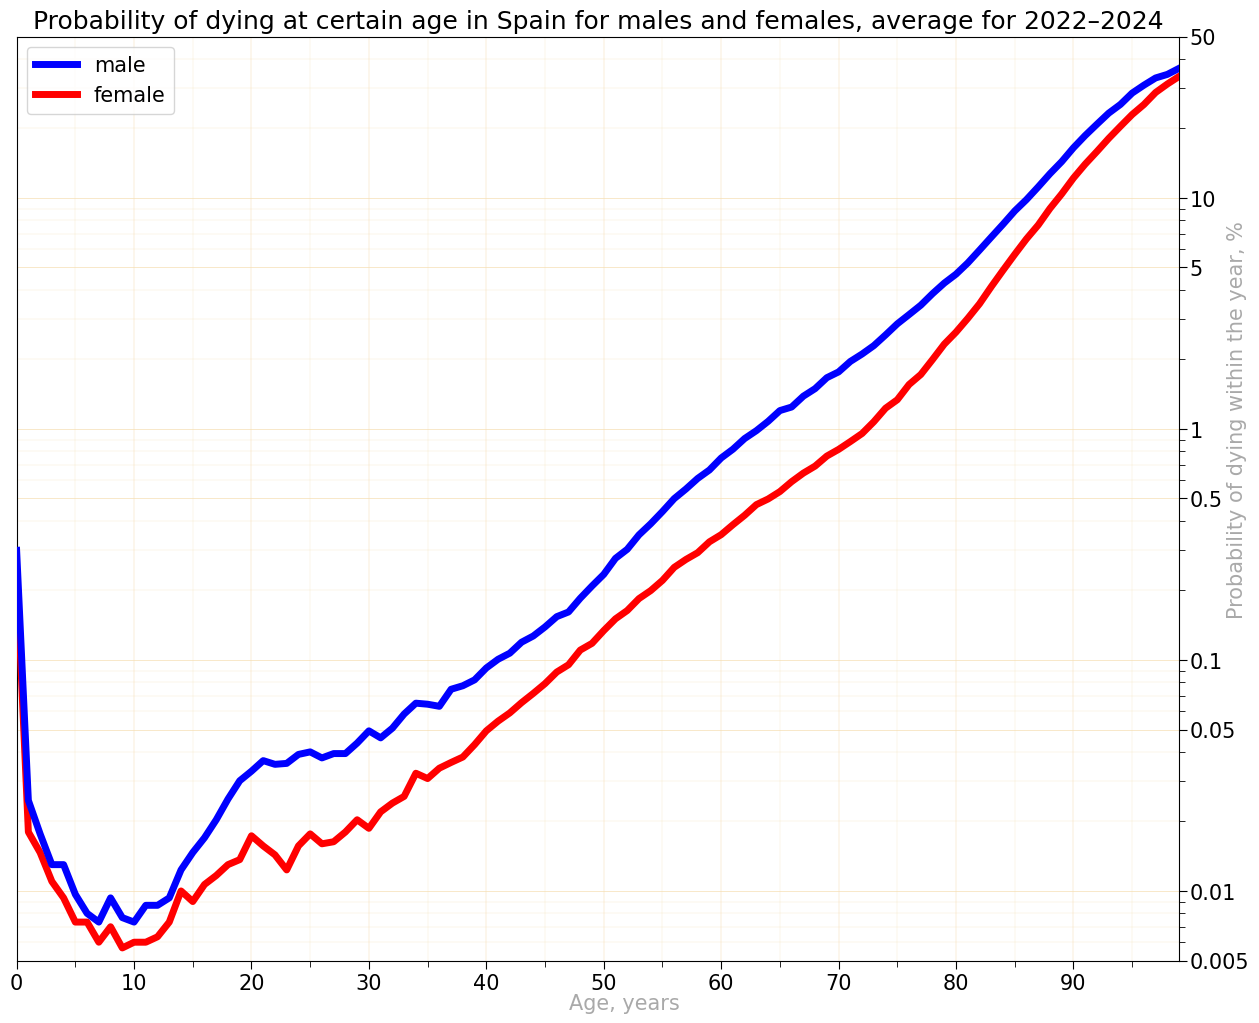

In [27]:
def create_chart_log(
        df, lang='en', dd_display='', ncol=1,
        plateau_years=plateau_years, show_plateau=False,
        age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=True,
        title_en="Title of the chart", title_ru="Заголовок графика",
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.set_yscale('log')       # Make Y-axis logarithmic  # alternative: plt.yscale('log')
    
    ax.yaxis.tick_right()                 # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    # ax.yaxis.set_major_locator(ticker.LogLocator())
    # ax.yaxis.set_minor_locator(ticker.LogLocator(subs=np.arange(1, 10) * 0.1))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)                                    # font size for tick labels
    labels_y = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
    plt.yticks(ticks=labels_y, labels=labels_y, fontsize=15)
    
    x_min = y_min = 0
    x_max = 99
    y_max = 50
    plt.xlim(0, 99)
    plt.ylim(0.005, 50)

    plt.grid(which='major', axis='x', color='wheat', linewidth=0.35)
    plt.grid(which='major', axis='y', color='wheat', linewidth=0.5)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    # for y_milestone in [0.1, 1, 10]:
    #     plt.axhline(y=y_milestone, color='wheat', linewidth=0.5)

    plt.title(title_ru if lang=='ru' else " " if lang=='nolang' else title_en,
              fontsize=17 if lang=='ru' else 18)
    plt.xlabel("              Возраст, годы" if lang=='ru' else
               " " if lang=='nolang' else
               "        Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("                      Вероятность смерти в течение года, %" if lang=='ru' else
               " " if lang=='nolang' else
               "                        Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=-16)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].nolang_name if lang=='nolang' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    # Calculate and show statistics about "plateau" (21–30 years, including endpoints)
    print(f"  —— The zone of the 'plateau' ({plateau_years.start}–{plateau_years.stop} years, incl.) ——")

    plateau_mortality_male   = df.loc['male', plateau_years].mean()
    plateau_mortality_female = df.loc['female', plateau_years].mean()
    print(f"Average mortality rate at the plateau, %:  ♂: {plateau_mortality_male:.3f},  ♀: {plateau_mortality_female:.3f}")
    
    le_average_plateau_male   = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_male)
    le_average_plateau_female = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_female)
    print("Life expectancy based on the average mortality rate at the plateau, years:  " +
          f"♂: {round(le_average_plateau_male, -1)},  ♀: {round(le_average_plateau_female, -1)}" +
          '\n')

    if show_plateau:  # show horizontal lines for the "plateaux"
        for y_plateau in [plateau_mortality_male, plateau_mortality_female]:
             plt.hlines(y_plateau, plateau_years.start, plateau_years.stop, color='lime', linewidth=2, alpha=0.5)

    # Calculate and show statistics about the zone of the Gompertz law of mortality (40–90 years)
    print(f"  —— The zone of the Gompertz law of mortality ({age_gompertz_start}–{age_gompertz_stop} age_gompertz_stop) ——")

    # Generate x-values for the considered interval
    x_gompertz = np.linspace(age_gompertz_start, age_gompertz_stop, age_gompertz_stop-age_gompertz_start+1)

    for group in ['male', 'female']:
        y_gompertz = df.loc[group, x_gompertz].values    # take the y values
        ln_y = np.log(y_gompertz)                        # take the logarithm of the y values
        b, ln_a = np.polyfit(x_gompertz, ln_y, deg=1)    # do linear regression
                                                         #    b - slope of the line
                                                         #    b - intersection of the 'ln a' with the y-axis
        a = np.exp(ln_a)                                 # recover the amplitude of the exponent
        print(f"Model for {group:>6}: y = {a:.6f} * exp({b:.6f} * x)")

        y_fit = a * np.exp(b * x_gompertz)               # approximated function

        ss_res = np.sum((y_gompertz - y_fit) ** 2)                # calculate the coefficient of determination
        ss_tot = np.sum((y_gompertz - np.mean(y_gompertz)) ** 2)
        r2 = 1 - ss_res / ss_tot
        print(f"Coefficient of determination (R²): {r2:.3f}")

        rate_perc, period_double = calculate_increase_rate_and_doubling_period(
            x_gompertz[0], x_gompertz[-1], y_fit[0], y_fit[-1])
        print(f"Annual increase: {rate_perc:6.3f} %,   doubling period: {period_double:6.3f} years")
        print()

        if show_gompertz:  # show sloped lines for the zone where Gompertz law is observed
            plt.plot(x_gompertz, y_fit, color='orange', linewidth=dd_display[group].width, alpha=0.5)
    
    plt.legend(loc='upper left', fontsize=15, ncol=ncol)
    
    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ' -nolang' if lang=='nolang' else ''}.png",
                    bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


if (WHAT_TO_EXPLORE == 'single'):
    title_en=f"Probability of dying at certain age in Spain in {SELECTED_YEAR} for males and females"
    title_ru=f"Вероятность смерти в определённом возрасте в Испании в {SELECTED_YEAR} для мужчин и женщин"
    file_name=f"Probability of Dying at Certain Age in Spain -log"
elif (WHAT_TO_EXPLORE == 'average'):
    title_en=f"Probability of dying at certain age in Spain for males and females, average for {NAME_FOR_AVERAGE}"
    title_ru=f"Вероятность смерти в определённом возрасте в Испании для мужчин и женщин, {NAME_FOR_AVERAGE}"
    file_name=f"Probability of Dying at Certain Age in Spain 3 years average -log"
else:
     raise ValueError(f"Variable WHAT_TO_EXPLORE has an invalid value: '{WHAT_TO_EXPLORE}'")
    
for lang in LANGS:
    create_chart_log(df.T.loc[['male', 'female']],
            dd_display=dd_display, lang=lang,
            plateau_years=plateau_years, show_plateau=False,
            age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=False,
            title_en=title_en, title_ru=title_ru, file_name=file_name)

  —— The zone of the 'plateau' (21–30 years, incl.) ——
Average mortality rate at the plateau, %:  ♂: 0.040,  ♀: 0.017
Life expectancy based on the average mortality rate at the plateau, years:  ♂: 2520,  ♀: 6060

  —— The zone of the Gompertz law of mortality (40–90 age_gompertz_stop) ——
Model for   male: y = 0.001536 * exp(0.101456 * x)
Coefficient of determination (R²): 0.986
Annual increase: 10.678 %,   doubling period:  6.832 years

Model for female: y = 0.000687 * exp(0.104172 * x)
Coefficient of determination (R²): 0.902
Annual increase: 10.979 %,   doubling period:  6.654 years



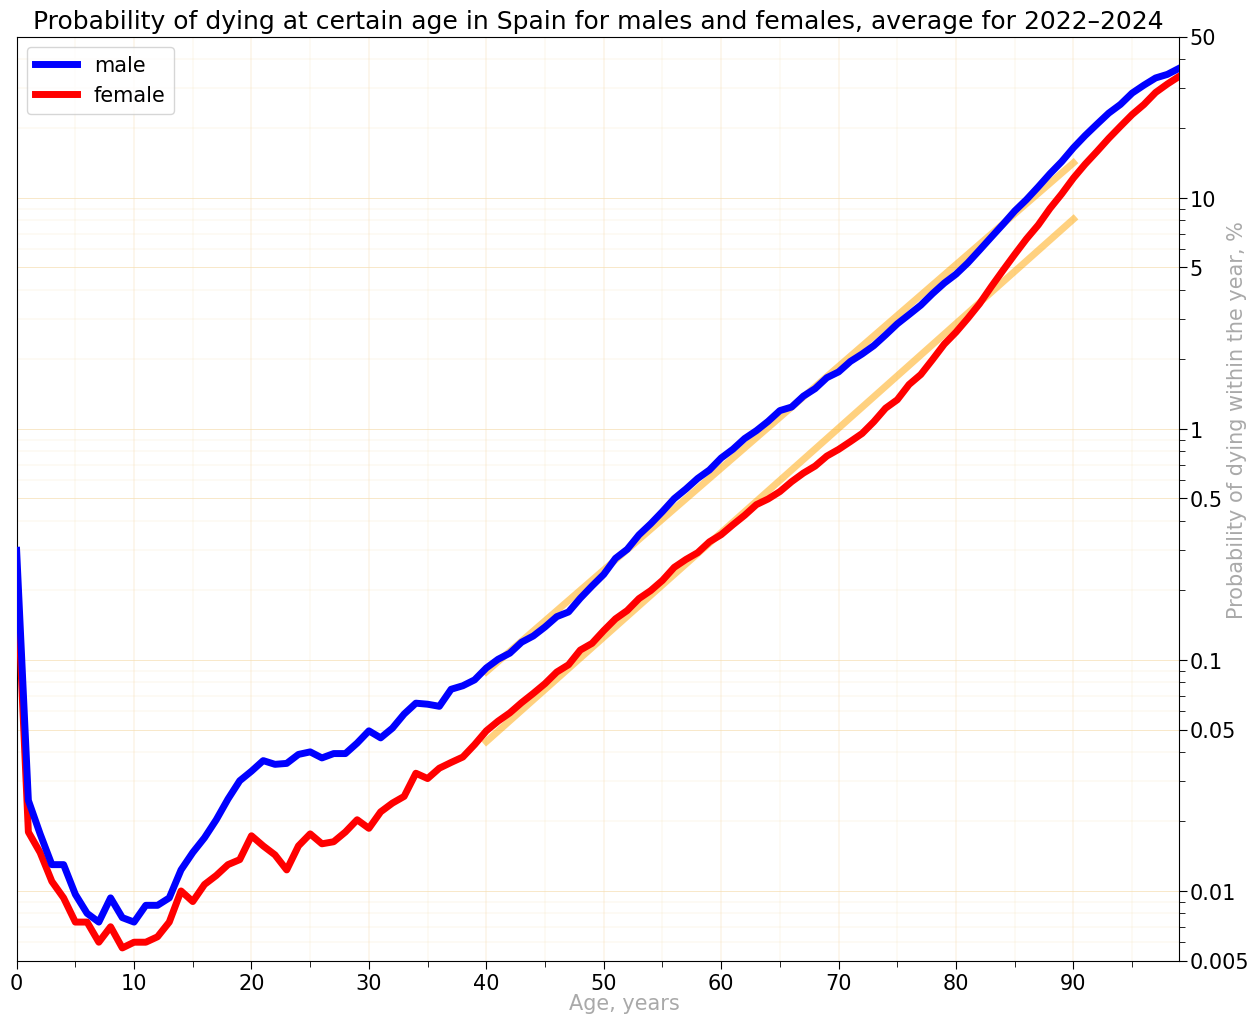

In [28]:
if (WHAT_TO_EXPLORE == 'single'):
    file_name=f"Probability of Dying at Certain Age in Spain -gompertz"
elif ((WHAT_TO_EXPLORE == 'average')):
    file_name=f"Probability of Dying at Certain Age in Spain 3 years average -gompertz"
else:
     raise ValueError(f"Variable WHAT_TO_EXPLORE has an invalid value: '{WHAT_TO_EXPLORE}'")
    
for lang in LANGS:
    create_chart_log(df.T.loc[['male', 'female']],
            dd_display=dd_display, lang=lang,
            plateau_years=plateau_years, show_plateau=False,
            age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=True,
            title_en=title_en, title_ru=title_ru, file_name=file_name)